In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import random

# Document Size (In inches)
width_min, width_max = 7.0, 8.0
height_min, height_max = 8.5, 11.0

ppi = 300

width = random.uniform(width_min, width_max) * ppi
height = random.uniform(height_min, height_max) * ppi
border_size = random.uniform(0.045, 0.08) * width

print(f"Width: {width}, Height: {height}")

Width: 2150.714609424131, Height: 3043.2838515069598


In [ ]:
def _hex_to_rgb(hex_color: str) -> tuple[int, int, int]:
    hex_color = hex_color.lstrip("#")
    if len(hex_color) == 3:
        hex_color = "".join(c * 2 for c in hex_color)
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))


def _rgb_to_hex(r: int, g: int, b: int) -> str:
    return f"#{r:02X}{g:02X}{b:02X}"


def lighten(hex_color: str, amount: int) -> str:
    """Lighten a hex color by `amount` percent (0-100)."""
    amount = max(0, min(100, amount))
    r, g, b = _hex_to_rgb(hex_color)
    r = int(r + (255 - r) * (amount / 100))
    g = int(g + (255 - g) * (amount / 100))
    b = int(b + (255 - b) * (amount / 100))
    return _rgb_to_hex(r, g, b)


def darken(hex_color: str, amount: int) -> str:
    """Darken a hex color by `amount` percent (0-100)."""
    amount = max(0, min(100, amount))
    r, g, b = _hex_to_rgb(hex_color)
    factor = 1 - (amount / 100)
    r = int(r * factor)
    g = int(g * factor)
    b = int(b * factor)
    return _rgb_to_hex(r, g, b)


def add_noise(hex_color: str, amount: int = 5) -> str:
    """Add a small random ± variation to each RGB channel (0-255). Makes solid colors look more like printed ink."""
    r, g, b = _hex_to_rgb(hex_color)
    r = max(0, min(255, r + random.randint(-amount, amount)))
    g = max(0, min(255, g + random.randint(-amount, amount)))
    b = max(0, min(255, b + random.randint(-amount, amount)))
    return _rgb_to_hex(r, g, b)


black = "#000000"

palette = {
    "green": ["#2F6F3E", "#3A7A3A", "#4F8A52"],
    "blue": ["#2C5C9A", "#3A6FB0", "#1F4A80"],
    "purple": ["#6C4A8A", "#5B3C77", "#7A5BA3"],
    "teal": ["#2F8A8B", "#1E7A7A", "#3A9FA0"]
}

# Base Colors
guilloche_family = random.choice(list(palette.keys()))
guilloche_color = random.choice(palette[guilloche_family])
background = add_noise(lighten(guilloche_color, random.randint(80, 90)), amount=5)
microtext = darken(guilloche_color, 30)
machine_text = black

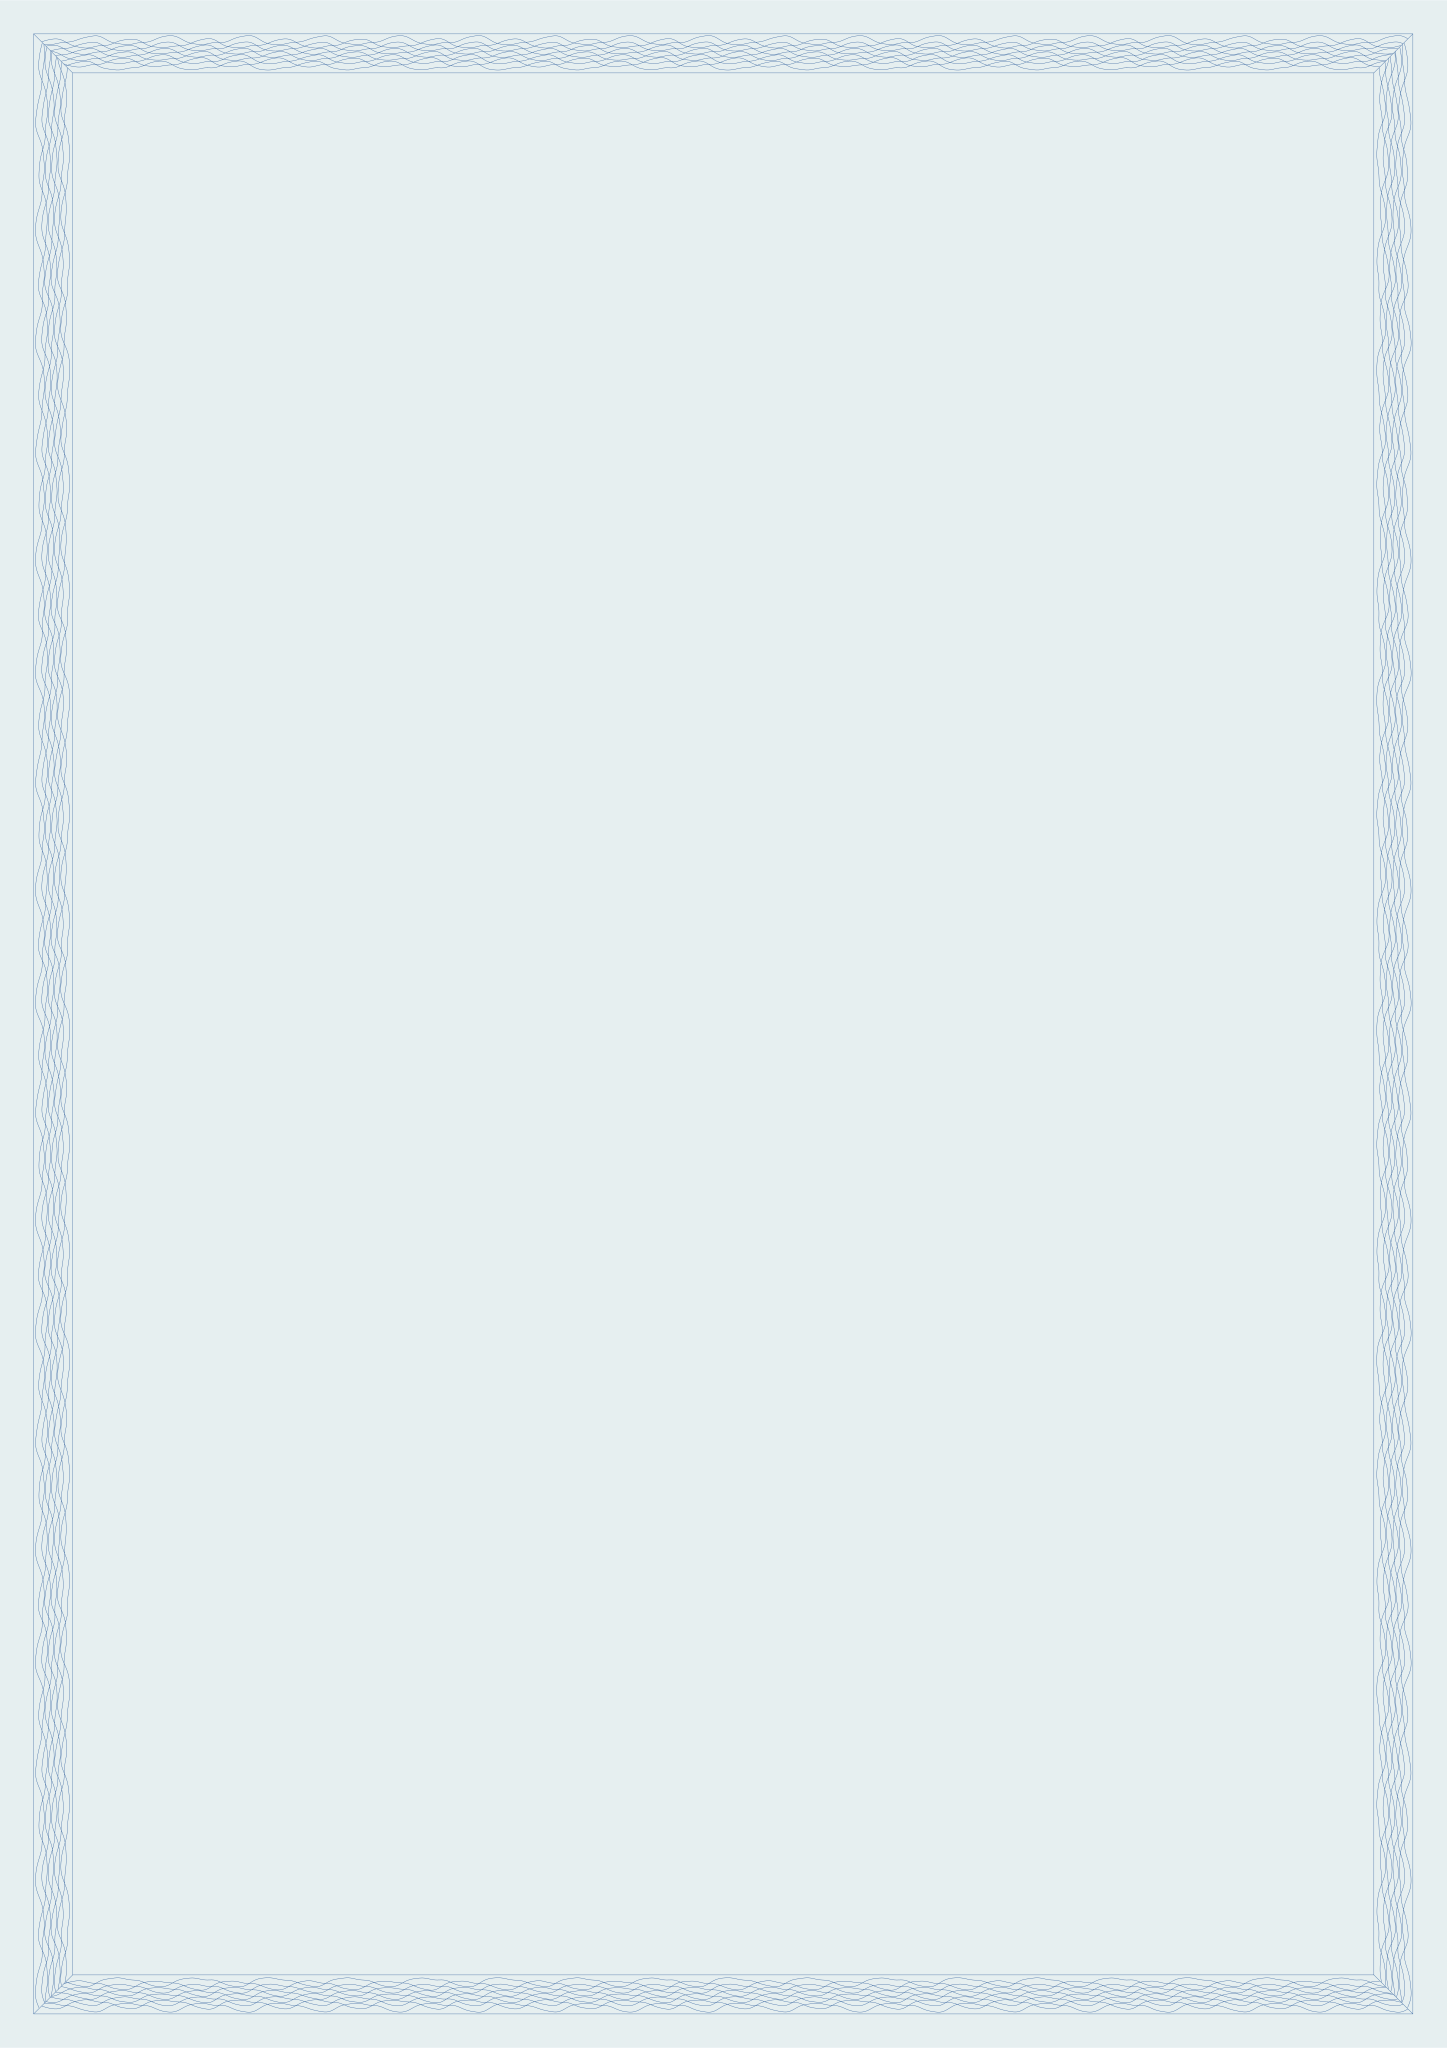

In [ ]:
import svgwrite
from IPython.display import SVG, display
from guilloche_border import BorderParams, add_border_to_drawing

document = svgwrite.Drawing(filename="document.svg", size=(width, height))
document.add(document.rect(insert=(0, 0), size=(width, height), fill=background))

params = BorderParams(
    width=int(width),
    height=int(height),
    margin=int(border_size * 0.35),
    band_thickness=int(border_size * 0.4),
    bg=background,
    fg=guilloche_color,
    num_strands=9,
    strand_spread=0.65,
    strand_phase_step=0.18,

)

add_border_to_drawing(document, params)

inner_margin = params.margin + params.band_thickness

# document.add(
#     document.rect(
#         insert=(inner_margin, inner_margin),
#         size=(
#             params.width - 2 * inner_margin,
#             params.height - 2 * inner_margin,
#         ),
#         fill=black,
#     )
# )

# Show inline in the notebook
svg_xml = document.tostring()
display(SVG(svg_xml))

# Still save to disk if you want the file as well
document.save()

# Second Attempt

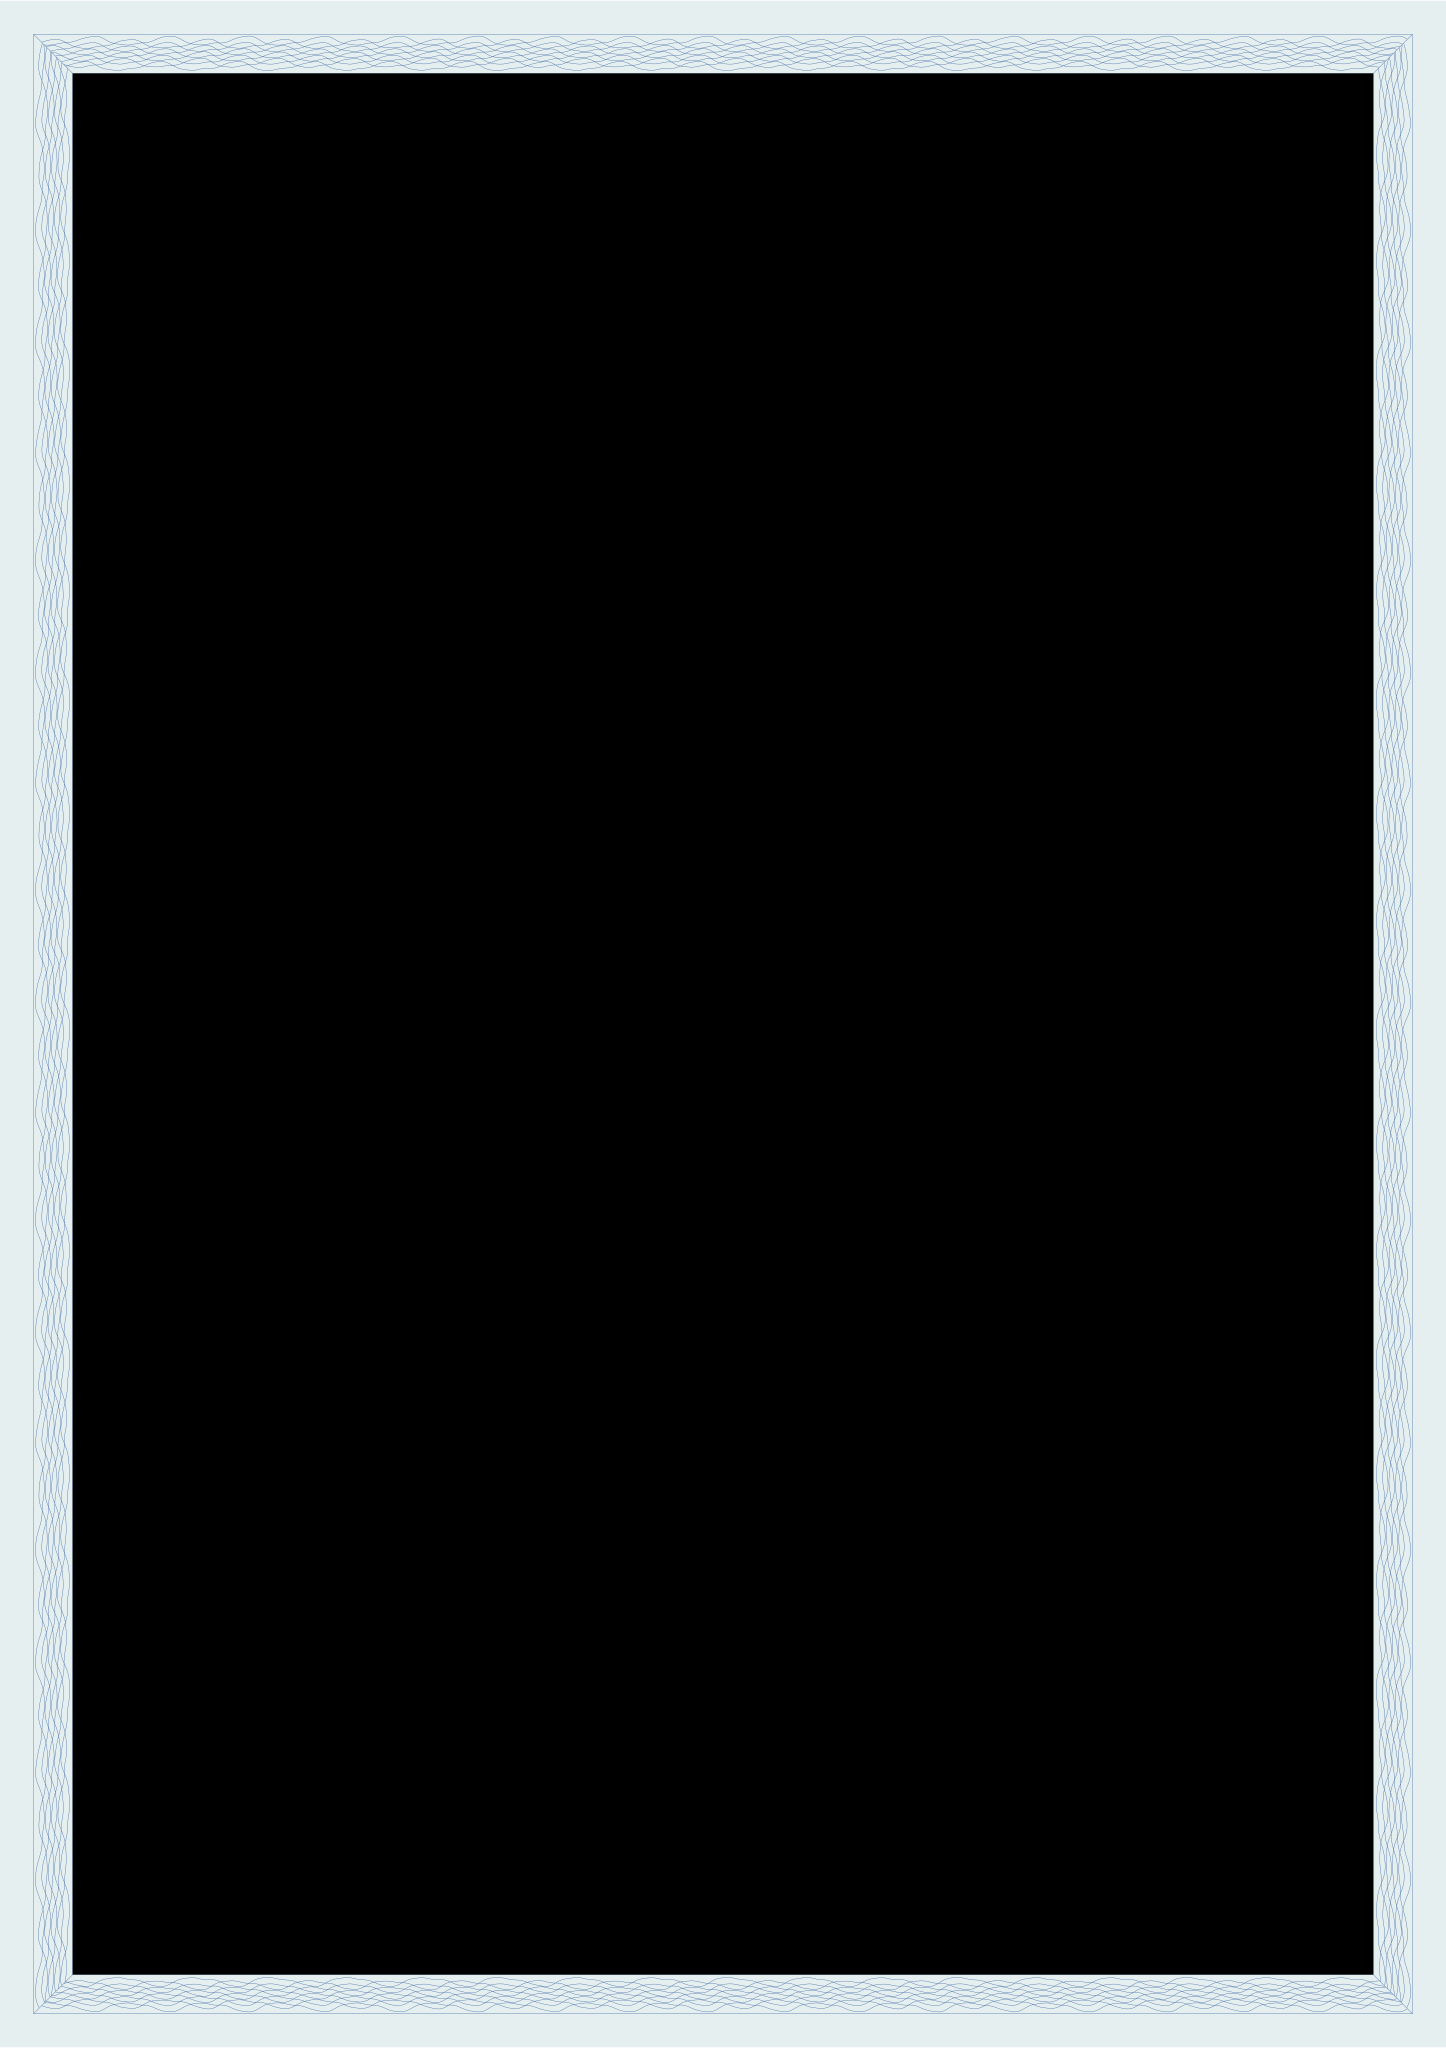

In [ ]:
import svgwrite
from IPython.display import SVG, display
from guilloche_border import BorderParams, render_border_svg

params = BorderParams(
    width=int(width),
    height=int(height),
    margin=int(border_size * 0.35),
    band_thickness=int(border_size * 0.4),
    bg=background,
    fg=guilloche_color,
)

# Render the guilloche border using the new library
drawing = render_border_svg(params)

inner_margin = params.margin + params.band_thickness

drawing.add(
    drawing.rect(
        insert=(inner_margin, inner_margin),
        size=(
            params.width - 2 * inner_margin,
            params.height - 2 * inner_margin,
        ),
        fill=black,
    )
)

svg_xml = drawing.tostring()
display(SVG(svg_xml))

drawing.saveas("document.svg")

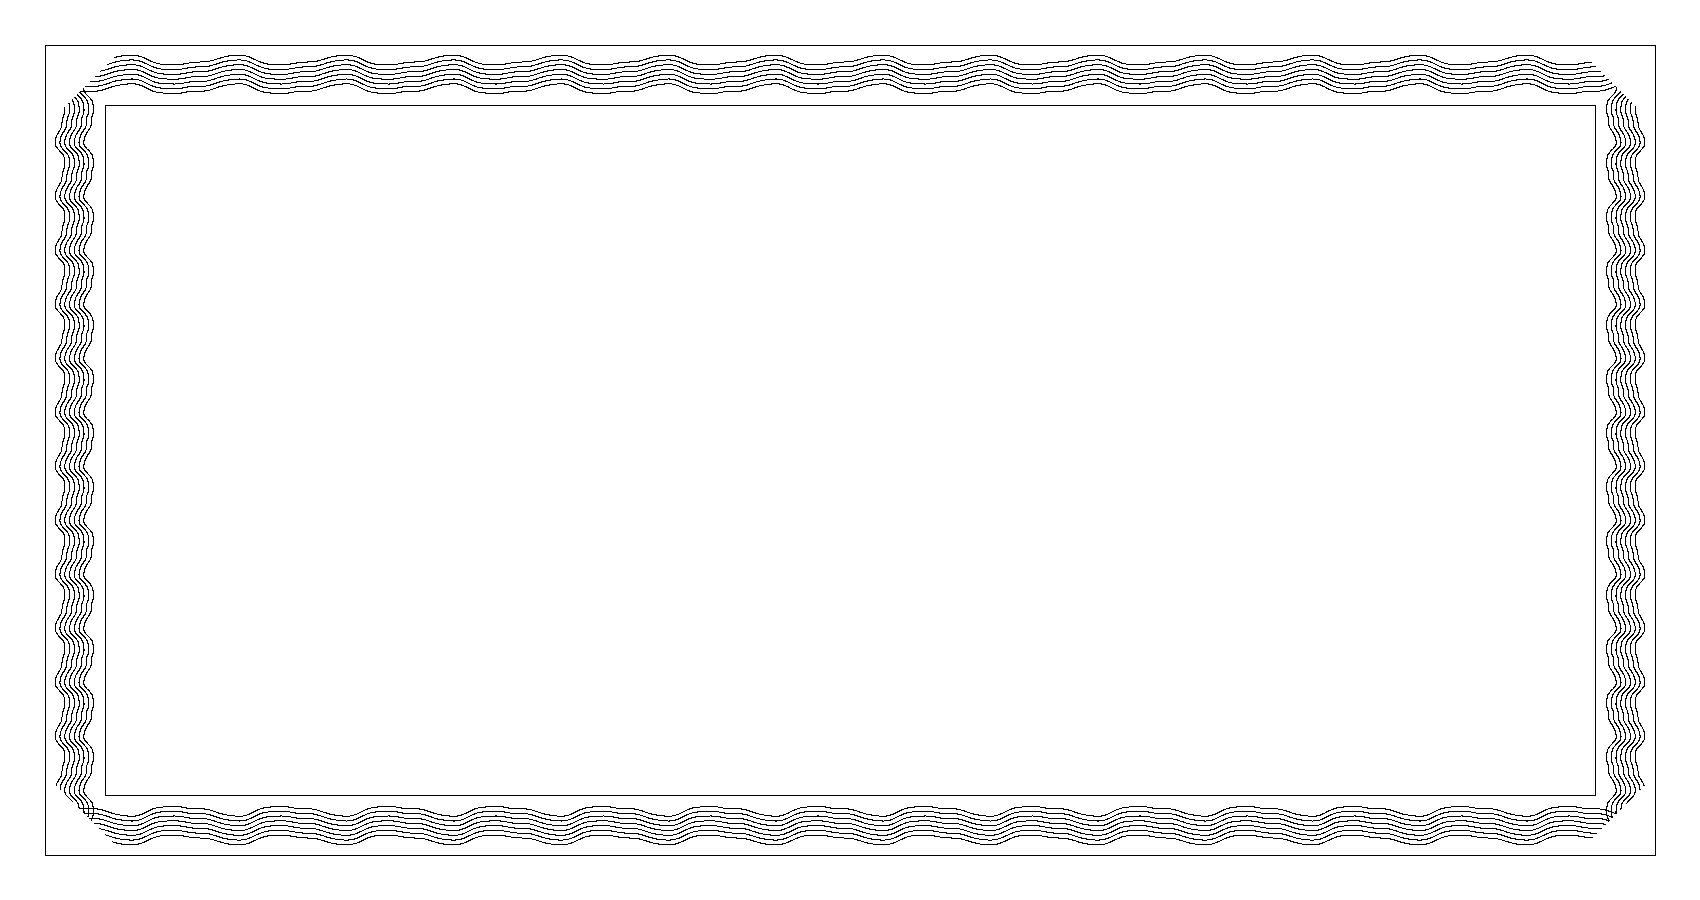

In [ ]:
import numpy as np
from dataclasses import dataclass
from PIL import Image, ImageDraw


@dataclass
class BorderParams:
    width: int = 1600
    height: int = 1000
    margin: int = 60
    band_thickness: int = 54
    samples: int = 3200
    bg: str = "white"
    fg: str = "black"
    line_width: int = 1

    # main wave family
    cycles_main: int = 18
    cycles_secondary: int = 36
    cycles_fine: int = 72

    amp_main: float = 0.22
    amp_secondary: float = 0.06
    amp_fine: float = 0.015

    phase_secondary: float = 0.8
    phase_fine: float = 1.7

    # family of parallel strands
    strand_offsets: tuple = (-0.26, -0.18, -0.10, 0.0, 0.10, 0.18, 0.26)

    # little phase shifts per strand
    strand_phase_step: float = 0.18

    # keep corners simple
    corner_trim: int = 22


def master_curve(xn: np.ndarray, p: BorderParams) -> np.ndarray:
    """
    Clean parent waveform.
    xn is normalized 0..1.
    """
    y = (
        p.amp_main * np.sin(2 * np.pi * p.cycles_main * xn)
        + p.amp_secondary * np.sin(
            2 * np.pi * p.cycles_secondary * xn + p.phase_secondary
        )
        + p.amp_fine * np.sin(
            2 * np.pi * p.cycles_fine * xn + p.phase_fine
        )
    )
    return y


def make_side_family(length: int, p: BorderParams):
    """
    Generate a controlled family of parallel ornamental strands for one side.
    Local coordinates:
      x = along the side
      y = inside the border band
    """
    x = np.linspace(0, length, p.samples)
    xn = x / length

    base = master_curve(xn, p)

    curves = []
    center_y = p.band_thickness / 2
    amp_px = p.band_thickness * 0.42

    for i, off in enumerate(p.strand_offsets):
        strand_phase = i * p.strand_phase_step

        # gentle strand-specific variation, not chaos
        strand_mod = (
            0.012 * np.sin(2 * np.pi * (p.cycles_main * 2) * xn + strand_phase)
            + 0.006 * np.sin(2 * np.pi * (p.cycles_secondary * 2) * xn + 1.7 * strand_phase)
        )

        y = center_y + p.band_thickness * off + amp_px * (base + strand_mod)
        curves.append(np.stack([x, y], axis=1))

    return curves


def transform_top(curve, x0, y0):
    out = curve.copy()
    out[:, 0] += x0
    out[:, 1] += y0
    return out


def transform_bottom(curve, x0, y0, band_thickness):
    out = curve.copy()
    out[:, 1] = band_thickness - out[:, 1]
    out[:, 0] += x0
    out[:, 1] += y0
    return out


def transform_left(curve, x0, y0):
    out = np.zeros_like(curve)
    out[:, 0] = curve[:, 1] + x0
    out[:, 1] = curve[:, 0] + y0
    return out


def transform_right(curve, x0, y0, band_thickness):
    out = np.zeros_like(curve)
    out[:, 0] = (band_thickness - curve[:, 1]) + x0
    out[:, 1] = curve[:, 0] + y0
    return out


def clip_points_to_rect(points, xmin, ymin, xmax, ymax):
    mask = (
        (points[:, 0] >= xmin)
        & (points[:, 0] <= xmax)
        & (points[:, 1] >= ymin)
        & (points[:, 1] <= ymax)
    )
    return points[mask]


def split_runs(points, max_jump=6.0):
    if len(points) < 2:
        return []

    runs = []
    start = 0
    for i in range(1, len(points)):
        jump = np.linalg.norm(points[i] - points[i - 1])
        if jump > max_jump:
            if i - start >= 2:
                runs.append(points[start:i])
            start = i

    if len(points) - start >= 2:
        runs.append(points[start:])

    return runs


def draw_runs(draw, runs, color, width):
    for run in runs:
        xy = [tuple(map(float, pt)) for pt in run]
        draw.line(xy, fill=color, width=width)


def draw_frame(draw, p: BorderParams):
    x0 = p.margin
    y0 = p.margin
    x1 = p.width - p.margin
    y1 = p.height - p.margin

    draw.rectangle([x0, y0, x1, y1], outline=p.fg, width=1)
    draw.rectangle(
        [x0 + p.band_thickness, y0 + p.band_thickness,
         x1 - p.band_thickness, y1 - p.band_thickness],
        outline=p.fg,
        width=1,
    )


def draw_corner_masks(draw, p: BorderParams):
    """
    Simple diagonal masks to keep corners crisp instead of chaotic.
    """
    x0 = p.margin
    y0 = p.margin
    x1 = p.width - p.margin
    y1 = p.height - p.margin
    b = p.band_thickness
    t = p.corner_trim

    tris = [
        [(x0, y0), (x0 + b + t, y0), (x0, y0 + b + t)],
        [(x1, y0), (x1 - b - t, y0), (x1, y0 + b + t)],
        [(x0, y1), (x0 + b + t, y1), (x0, y1 - b - t)],
        [(x1, y1), (x1 - b - t, y1), (x1, y1 - b - t)],
    ]
    for tri in tris:
        draw.polygon(tri, fill=p.bg)


def render_border(p: BorderParams) -> Image.Image:
    img = Image.new("RGB", (p.width, p.height), p.bg)
    draw = ImageDraw.Draw(img)

    x0 = p.margin
    y0 = p.margin
    x1 = p.width - p.margin
    y1 = p.height - p.margin
    b = p.band_thickness

    top_len = x1 - x0
    side_len = y1 - y0

    top_curves = make_side_family(top_len, p)
    side_curves = make_side_family(side_len, p)

    rects = {
        "top": (x0 + p.corner_trim, y0, x1 - p.corner_trim, y0 + b),
        "bottom": (x0 + p.corner_trim, y1 - b, x1 - p.corner_trim, y1),
        "left": (x0, y0 + p.corner_trim, x0 + b, y1 - p.corner_trim),
        "right": (x1 - b, y0 + p.corner_trim, x1, y1 - p.corner_trim),
    }

    # top
    for curve in top_curves:
        pts = transform_top(curve, x0, y0)
        pts = clip_points_to_rect(pts, *rects["top"])
        runs = split_runs(pts)
        draw_runs(draw, runs, p.fg, p.line_width)

    # bottom
    for curve in top_curves:
        pts = transform_bottom(curve, x0, y1 - b, b)
        pts = clip_points_to_rect(pts, *rects["bottom"])
        runs = split_runs(pts)
        draw_runs(draw, runs, p.fg, p.line_width)

    # left
    for curve in side_curves:
        pts = transform_left(curve, x0, y0)
        pts = clip_points_to_rect(pts, *rects["left"])
        runs = split_runs(pts)
        draw_runs(draw, runs, p.fg, p.line_width)

    # right
    for curve in side_curves:
        pts = transform_right(curve, x1 - b, y0, b)
        pts = clip_points_to_rect(pts, *rects["right"])
        runs = split_runs(pts)
        draw_runs(draw, runs, p.fg, p.line_width)

    draw_corner_masks(draw, p)
    draw_frame(draw, p)
    return img


from IPython.display import display

params = BorderParams(
    width=1700,
    height=900,
    margin=45,
    band_thickness=60,
    samples=4000,
    cycles_main=15,
    cycles_secondary=30,
    cycles_fine=60,
    amp_main=0.18,
    amp_secondary=0.045,
    amp_fine=0.01,
    strand_offsets=(-0.24, -0.16, -0.08, 0.0, 0.08, 0.16, 0.24),
    strand_phase_step=0.14,
    corner_trim=20,
)

img = render_border(params)

# Show inline in the notebook
display(img)

# Still save to disk if you want the file as well
img.save("clean_guilloche_border.png")